In [1]:
!pip install albumentations

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import albumentations as A
from google.colab import files

In [4]:
!pip install segmentation-models-pytorch
!pip install pycocotools albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.6 MB/s eta 0:00:00


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
!pip install pycocotools

In [8]:
from pycocotools.coco import COCO

In [10]:
!ls /content/drive/MyDrive

 17109614855781527023913702020336-compressed.jpg.jpg
'2341018060 (2).pdf'
 254.xlsx
'5th sem admit card.pdf'
'admit card (1).pdf'
'admit card.pdf'
'CNC-project report format-1.gdoc'
'CNC-project report format-1.pdf'
'CN Project 5 report.docx'
'Colab Notebooks'
'Computer Institute Management System Project.gdoc'
'Computer Institute Management System Project.pdf'
'Copy of PYQ_MidSem_COA (1).pdf'
'Copy of PYQ_MidSem_COA.pdf'
"Copy of White and Black Illustrative National Engineer's Day Instagram Post_20250915_140005_0000.png"
 d7d91c24-fc8f-48ab-b199-471c3bf59095_copy.pdf
'file_00000000bf9061f981a7907ee085d142 (1).png'
'file_00000000bf9061f981a7907ee085d142 (2).png'
 file_00000000bf9061f981a7907ee085d142.png
'From the Resume, day 1'
'Gmail - SOA B.TECH. Orientation Class (1).pdf'
'Gmail - SOA BTECH PROVISONAL ALLOTMENT (1).pdf'
 IMG-20231113-WA0025.jpeg
 IMG-20231215-WA0016.jpg
'IMG20240925225409 (1).jpg'
 IMG20240925225409.jpg
'IMG_20250315_222123 (1).jpg'
'IMG_20250315_222123 (2).jpg'
 

In [11]:
!ls /content/drive/MyDrive/VisionExtract

best_model.pth	final_model.pth  model.pth


In [12]:
!ls /content

drive  sample_data


In [13]:
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q train2017.zip
!unzip -q annotations_trainval2017.zip

--2026-03-15 06:37:17--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.52.65, 16.15.207.224, 52.216.208.233, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.52.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  17.6MB/s    in 18m 43s 

2026-03-15 06:56:00 (16.4 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-03-15 06:56:00--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.196.33, 3.5.19.151, 3.5.25.142, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.196.33|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_t

In [14]:
!mkdir -p /content/drive/MyDrive/VisionExtract

!mv /content/train2017 /content/drive/MyDrive/VisionExtract/
!mv /content/annotations /content/drive/MyDrive/VisionExtract/

In [15]:
DATASET_PATH = "/content/drive/MyDrive/VisionExtract"

coco = COCO(f"{DATASET_PATH}/annotations/instances_train2017.json")

loading annotations into memory...
Done (t=14.76s)
creating index...
index created!


In [18]:
DATASET_PATH = "/content/drive/MyDrive/VisionExtract"

ANNOTATION_PATH = f"{DATASET_PATH}/annotations/instances_train2017.json"

coco = COCO(ANNOTATION_PATH)

loading annotations into memory...
Done (t=14.93s)
creating index...
index created!


In [24]:
!ls /content

annotations_trainval2017.zip  drive  sample_data  train2017.zip


In [25]:
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/VisionExtract/final_model.pth")
)

model.eval()

print("Milestone 2 model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Milestone 2 model loaded


In [28]:
from google.colab import files
uploaded = files.upload()

Saving IMG_20250315_222123.jpg to IMG_20250315_222123.jpg


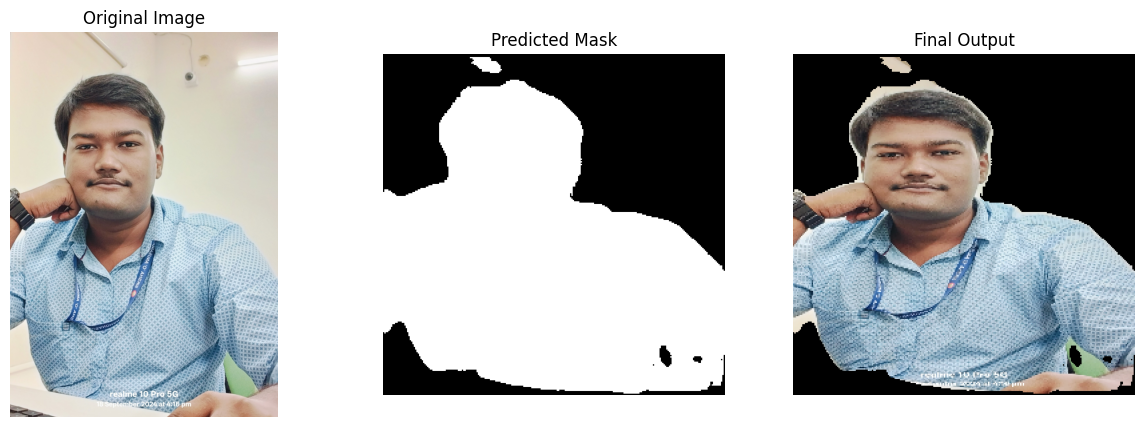

In [29]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np

# Load uploaded image
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

original = image.copy()

# Resize for model
image = cv2.resize(image, (256,256))
image = image / 255.0

image = torch.tensor(image).permute(2,0,1).float().unsqueeze(0).to(device)

# Predict mask
model.eval()

with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred = (pred > 0.3).float()

# Apply mask
output = image * pred

mask = pred.squeeze().cpu().numpy()
result = output.squeeze().cpu().permute(1,2,0).numpy()

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Final Output")
plt.imshow(result)
plt.axis("off")

plt.show()

In [ ]:
model.load_state_dict(
    torch.load("models/milestone3_model.pth", map_location=device)
)